### ***Data Processing***
-------------------------------------------------

In [1]:
# importing the necessary libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import shap
from sklearn.metrics import make_scorer, f1_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
regensburg_pediatric_appendicitis = fetch_ucirepo(id=938) 
  
# data (as pandas dataframes) 
X = regensburg_pediatric_appendicitis.data.features 
y = regensburg_pediatric_appendicitis.data.targets 

In [ ]:
type(X), type(y)

In [369]:
X.head(10) #print out the 10 first value aof the dataset

,Age,BMI,Sex,Height,Weight,Length_of_Stay,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_on_US,Appendix_Diameter,...,Abscess_Location,Pathological_Lymph_Nodes,Lymph_Nodes_Location,Bowel_Wall_Thickening,Conglomerate_of_Bowel_Loops,Ileus,Coprostasis,Meteorism,Enteritis,Gynecological_Findings
0,12.68,16.9,female,148.0,37.0,3.0,4.0,3.0,yes,7.1,...,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14.10,31.9,male,147.0,69.5,2.0,5.0,4.0,no,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,NaN
2,14.14,23.3,female,163.0,62.0,4.0,5.0,3.0,no,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,yes,NaN
3,16.37,20.6,female,165.0,56.0,3.0,7.0,6.0,no,NaN,...,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,yes,NaN
4,11.08,16.9,female,163.0,45.0,3.0,5.0,6.0,yes,7.0,...,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,yes,NaN
5,11.05,30.7,male,121.0,45.0,3.0,6.0,7.0,no,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,8.98,19.4,female,140.0,38.5,3.0,5.0,6.0,no,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7.06,NaN,female,NaN,21.5,2.0,3.0,3.0,no,NaN,...,NaN,yes,re UB,no,NaN,NaN,NaN,NaN,NaN,NaN
8,7.90,15.7,male,131.0,26.7,3.0,7.0,6.0,yes,3.7,...,NaN,yes,NaN,NaN,NaN,NaN,NaN,yes,NaN,NaN
9,14.34,14.9,male,174.0,45.5,3.0,4.0,4.0,yes,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [370]:
X.shape # print out the shape of the dataset

(782, 53)

In [371]:
X.isna().sum().sort_values() # printout for every variable ne number of missing value

Age                                   1
Sex                                   2
Weight                                3
Length_of_Stay                        4
US_Performed                          4
Appendix_on_US                        5
WBC_Count                             6
Body_Temperature                      7
Nausea                                8
Lower_Right_Abd_Pain                  8
Migratory_Pain                        9
Peritonitis                           9
Loss_of_Appetite                     10
CRP                                  11
Contralateral_Rebound_Tenderness     15
Coughing_Pain                        16
Stool                                17
Hemoglobin                           18
RBC_Count                            18
Thrombocyte_Count                    18
Height                               26
RDW                                  26
BMI                                  27
Dysuria                              29
Psoas_Sign                           37


In [372]:
# search for outliers
columns = list(X.select_dtypes(include = ['number']).columns)
outliers = {}
for column in columns:
    Q1 = X[column].quantile(.25)
    Q3 = X[column].quantile(.75)
    IQR = Q3 - Q1
    outliers[column] = float(((X[column] < Q1 - 1.5 * IQR) | (X[column] > Q3 + 1.5 * IQR)).sum())

outliers # dictionary containing number of outliers for each column

{'Age': 5.0,
 'BMI': 23.0,
 'Height': 12.0,
 'Weight': 8.0,
 'Length_of_Stay': 44.0,
 'Alvarado_Score': 0.0,
 'Paedriatic_Appendicitis_Score': 0.0,
 'Appendix_Diameter': 10.0,
 'Body_Temperature': 12.0,
 'WBC_Count': 6.0,
 'Neutrophil_Percentage': 1.0,
 'Segmented_Neutrophils': 0.0,
 'RBC_Count': 14.0,
 'Hemoglobin': 16.0,
 'RDW': 23.0,
 'Thrombocyte_Count': 9.0,
 'CRP': 85.0}

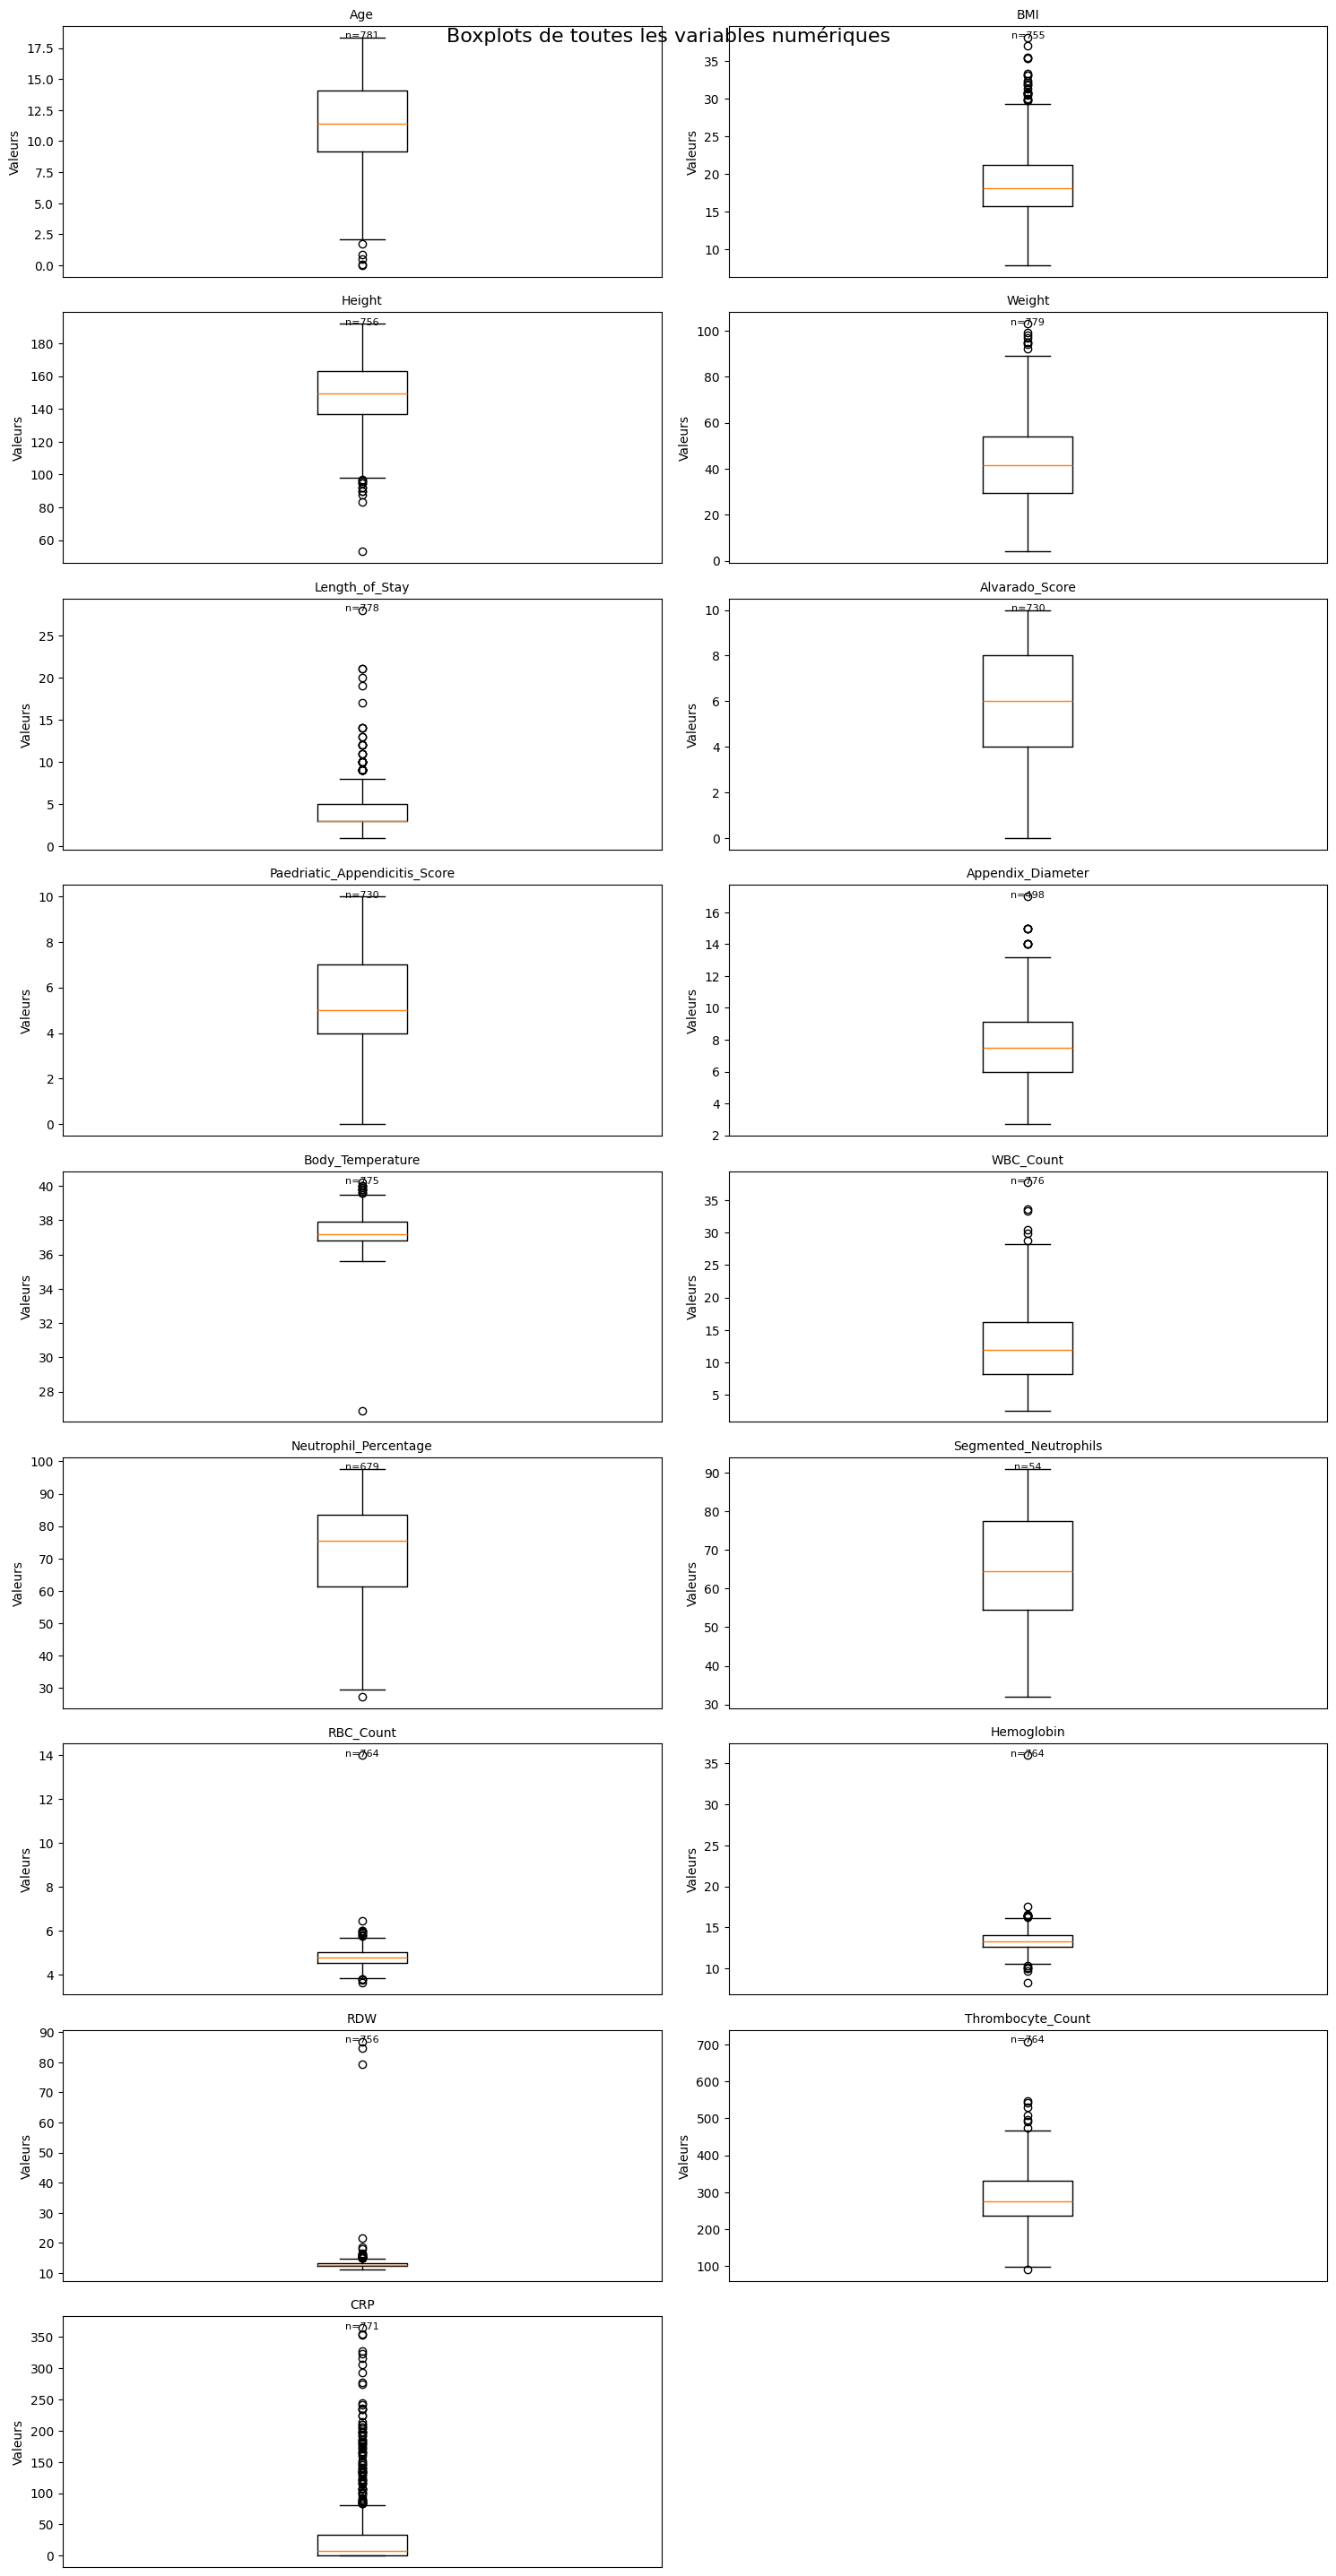

In [373]:
# Crée une figure avec 9 lignes et 2 colonnes
fig, axes = plt.subplots(9, 2, figsize=(15, 30))  # Ajuste la hauteur selon besoin
fig.suptitle('Boxplots de toutes les variables numériques', fontsize=16, y=0.95)

# Aplatit le tableau d'axes pour faciliter l'itération
axes_flat = axes.flatten()

for i, col in enumerate(columns):
    if i < len(axes_flat):  # Évite de dépasser le nombre de subplots
        # Nettoie les données (enlève les NaN)
        data_clean = X[col].dropna()
        
        # Crée le boxplot dans le subplot correspondant
        axes_flat[i].boxplot(data_clean)
        axes_flat[i].set_title(col, fontsize=10)
        axes_flat[i].set_ylabel('Valeurs')
        axes_flat[i].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        
        # Ajoute le nombre d'observations
        axes_flat[i].text(0.5, 0.95, f'n={len(data_clean)}', 
                         transform=axes_flat[i].transAxes, 
                         ha='center', fontsize=8)

# Cache les subplots en trop s'il y en a
for j in range(len(columns), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(top=0.95)  # Ajuste pour laisser de la place au titre principal
plt.show()

# To see the distribution around the median for each column

In [374]:
y # to know column in target dataset

,Management,Severity,Diagnosis
0,conservative,uncomplicated,appendicitis
1,conservative,uncomplicated,no appendicitis
2,conservative,uncomplicated,no appendicitis
3,conservative,uncomplicated,no appendicitis
4,conservative,uncomplicated,appendicitis
...,...,...,...
777,primary surgical,uncomplicated,appendicitis
778,secondary surgical,complicated,appendicitis
779,primary surgical,uncomplicated,appendicitis
780,primary surgical,uncomplicated,appendicitis


In [375]:
# data balance test
app = (y[y['Diagnosis'] == 'appendicitis'].shape[0] / 782) * 100
no_app = 100 - app

print('appendicitis =', app, '%')
print('no appendicitis =', no_app, '%')

appendicitis = 59.20716112531969 %
no appendicitis = 40.79283887468031 %


In [376]:
# search for correlation between
n1 = len(columns)
y_columns = list(y.columns)

correlation = {columns[i] : [] for i in range(n1)}
y0 = y[y_columns]
y0 = pd.get_dummies(y0, columns=y_columns)
y_columns = list(y0.columns)
n2 = len(y_columns)

for i in range(n1):
    for j in range(n2):
        r = round(float(X[columns[i]].corr(y0[y_columns[j]])), 2)
        correlation[columns[i]].append(r)
    
print(y_columns)
correlation

['Management_conservative', 'Management_primary surgical', 'Management_secondary surgical', 'Management_simultaneous appendectomy', 'Severity_complicated', 'Severity_uncomplicated', 'Diagnosis_appendicitis', 'Diagnosis_no appendicitis']


{'Age': [0.14, -0.18, 0.1, 0.04, -0.16, 0.16, -0.09, 0.09],
 'BMI': [0.12, -0.12, -0.01, -0.0, -0.1, 0.1, -0.13, 0.12],
 'Height': [0.13, -0.15, 0.06, 0.02, -0.14, 0.14, -0.07, 0.06],
 'Weight': [0.13, -0.14, 0.02, 0.01, -0.11, 0.11, -0.1, 0.1],
 'Length_of_Stay': [-0.62, 0.62, 0.05, -0.0, 0.66, -0.66, 0.39, -0.38],
 'Alvarado_Score': [-0.41, 0.4, 0.05, -0.02, 0.3, -0.3, 0.42, -0.42],
 'Paedriatic_Appendicitis_Score': [-0.31,
  0.31,
  0.02,
  0.03,
  0.26,
  -0.26,
  0.35,
  -0.35],
 'Appendix_Diameter': [-0.5, 0.48, 0.07, nan, 0.27, -0.27, 0.63, -0.63],
 'Body_Temperature': [-0.25, 0.28, -0.08, -0.01, 0.26, -0.26, 0.16, -0.16],
 'WBC_Count': [-0.4, 0.42, -0.02, -0.03, 0.37, -0.37, 0.36, -0.36],
 'Neutrophil_Percentage': [-0.37, 0.38, -0.01, 0.03, 0.29, -0.29, 0.35, -0.35],
 'Segmented_Neutrophils': [-0.44, 0.37, 0.19, nan, 0.37, -0.37, 0.54, -0.54],
 'RBC_Count': [0.04, -0.04, -0.01, -0.02, -0.04, 0.04, -0.03, 0.03],
 'Hemoglobin': [0.01, -0.03, 0.04, 0.02, -0.01, 0.01, 0.0, -0.0],
 

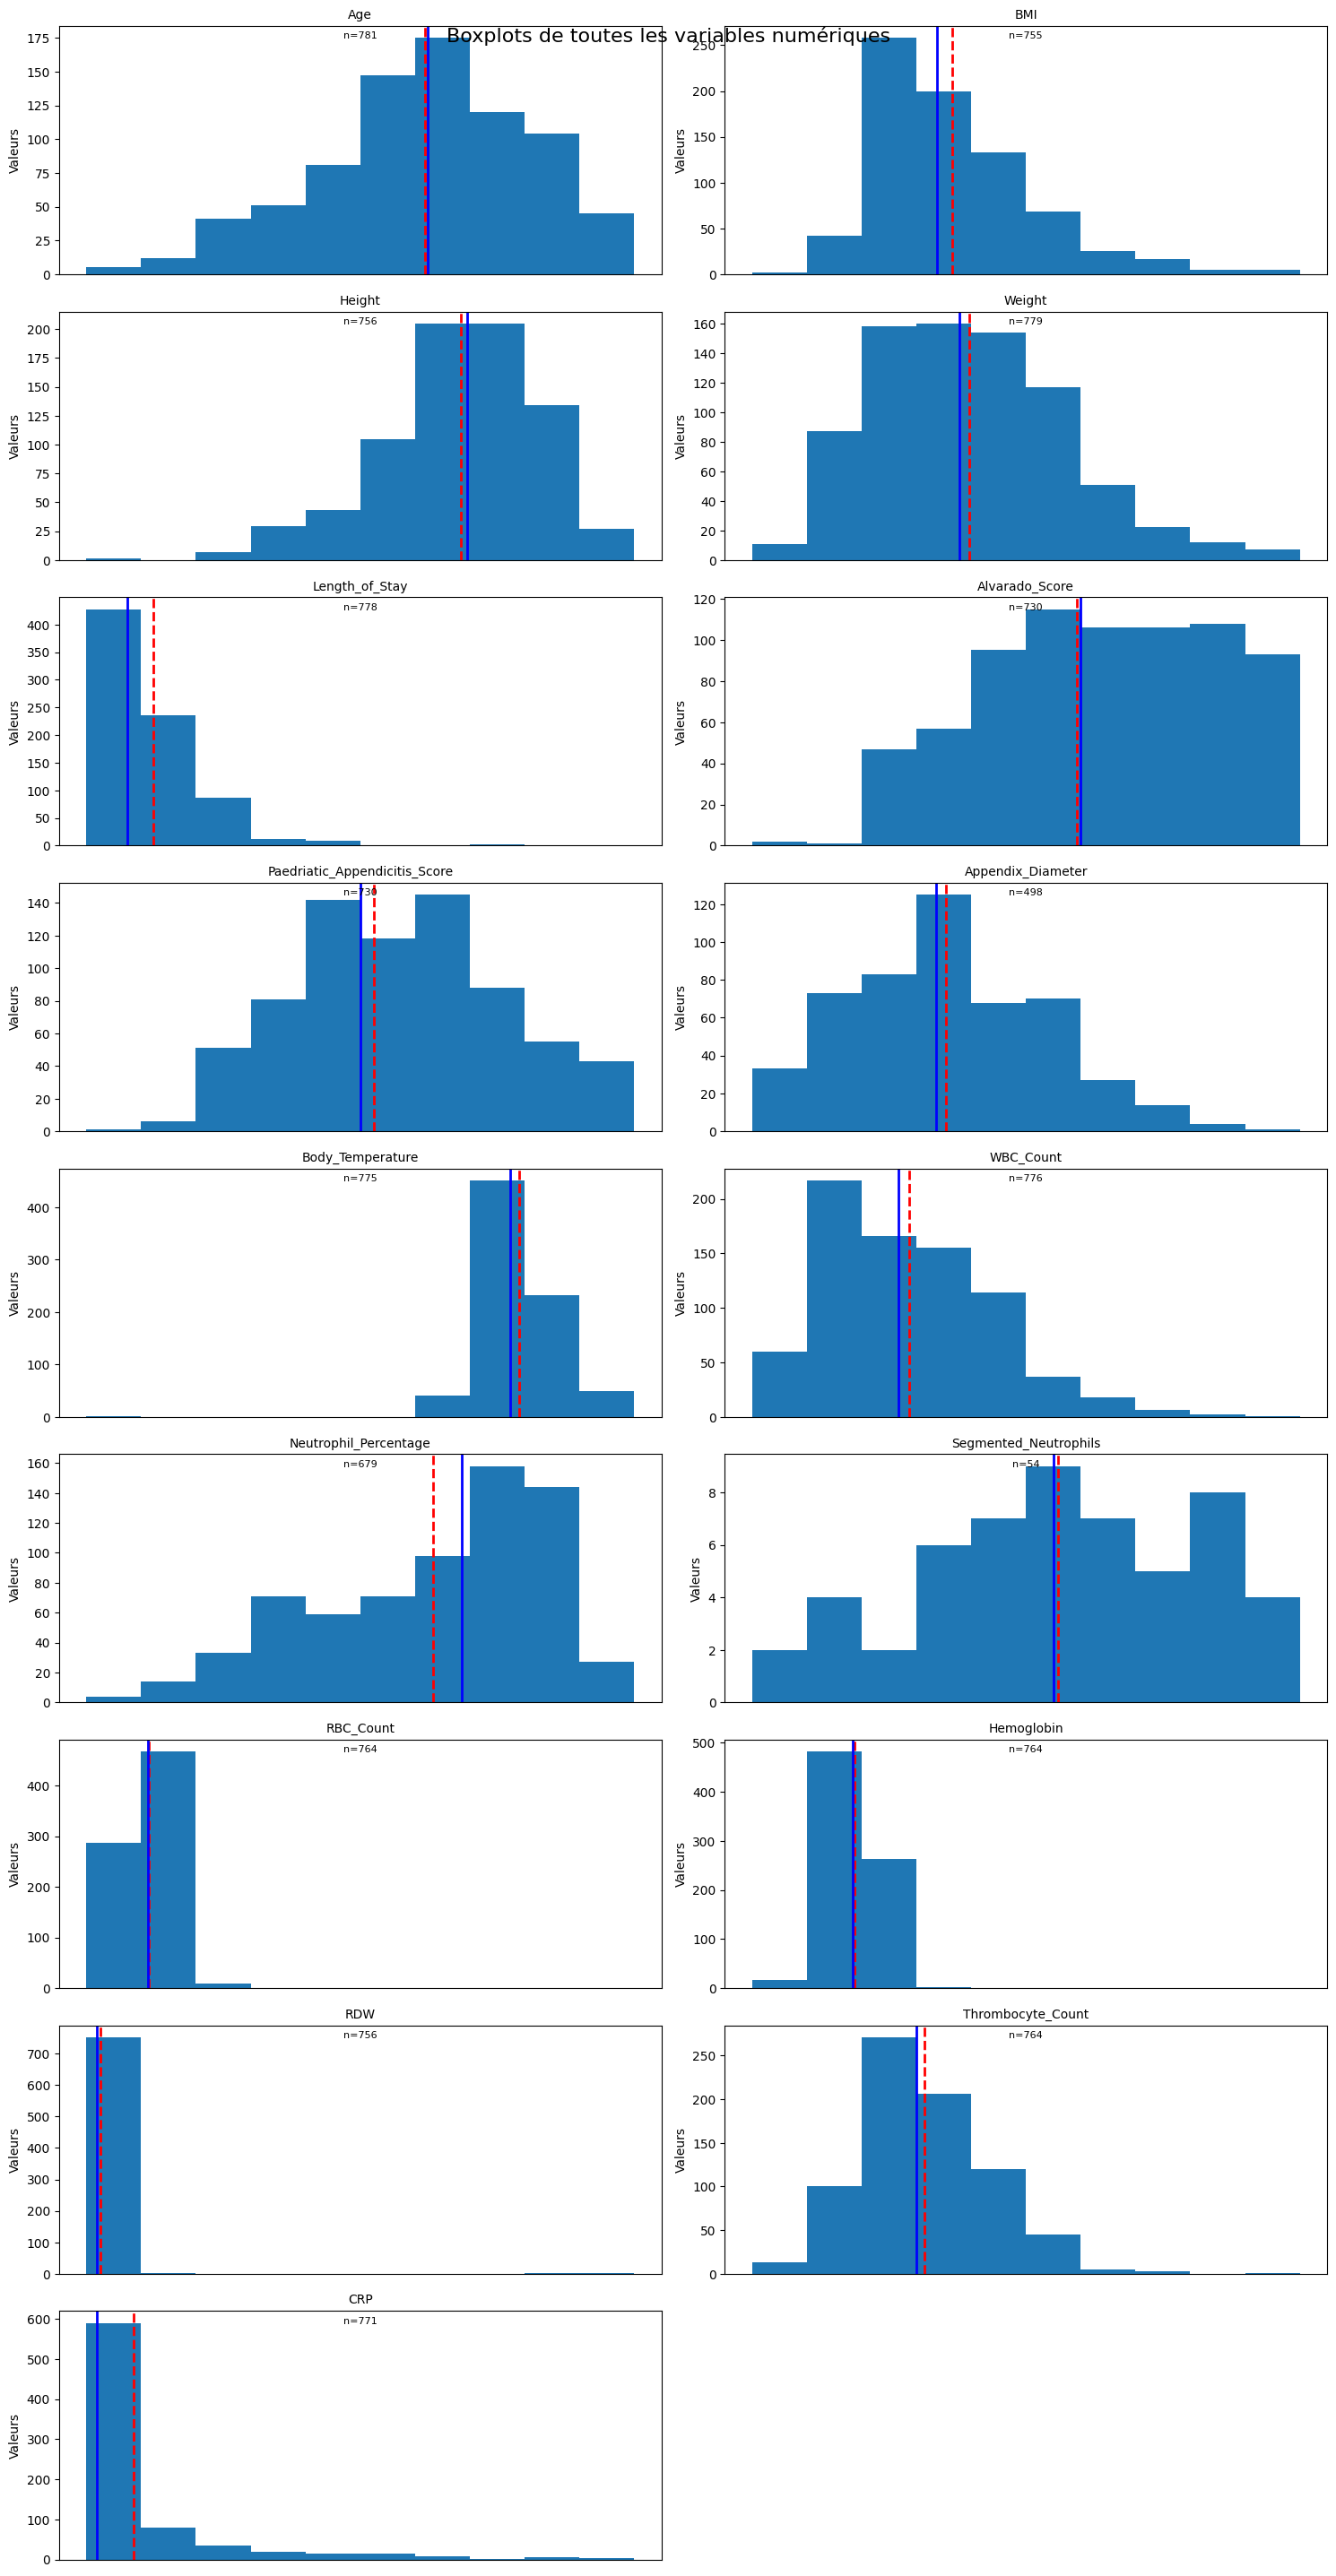

In [377]:
# Crée une figure avec 9 lignes et 2 colonnes
fig, axes = plt.subplots(9, 2, figsize=(15, 30))  # Ajuste la hauteur selon besoin
fig.suptitle('Boxplots de toutes les variables numériques', fontsize=16, y=0.95)

# Aplatit le tableau d'axes pour faciliter l'itération
axes_flat = axes.flatten()

for i, col in enumerate(columns):
    if i < len(axes_flat):  # Évite de dépasser le nombre de subplots
        # Nettoie les données (enlève les NaN)
        data_clean = X[col].dropna()
        
        # Crée le boxplot dans le subplot correspondant
        axes_flat[i].hist(data_clean)
        # Calcule moyenne et médiane
        moyenne = data_clean.mean()
        mediane = data_clean.median()
        
        # Ajoute les lignes verticales pour la moyenne et la médiane
        axes_flat[i].axvline(moyenne, color='red', linestyle='--', linewidth=2, label=f'Moyenne={moyenne:.2f}')
        axes_flat[i].axvline(mediane, color='blue', linestyle='-', linewidth=2, label=f'Médiane={mediane:.2f}')
        axes_flat[i].set_title(col, fontsize=10)
        axes_flat[i].set_ylabel('Valeurs')
        axes_flat[i].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        
        # Ajoute le nombre d'observations
        axes_flat[i].text(0.5, 0.95, f'n={len(data_clean)}', 
                         transform=axes_flat[i].transAxes, 
                         ha='center', fontsize=8)

# Cache les subplots en trop s'il y en a
for j in range(len(columns), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(top=0.95)  # Ajuste pour laisser de la place au titre principal
plt.show()


# these histograms allows us to know what is the best choice between the mean and the median to replace missing values

### ***Training ML Models***
---------------------------------------------------------------

In [378]:
def data_prossess(X, y, cols_used : list):
    data = X.loc[:, cols_used] # subsets of datasets to train futurs models
    for col in cols_used:
        data[col] = data[col].fillna(data[col].median()) # replacing all missing values
    return data

In [379]:
cols_used = ['Length_of_Stay', 'Alvarado_Score', 'Appendix_Diameter', 'WBC_Count', 'Neutrophil_Percentage', 'Segmented_Neutrophils', 'Body_Temperature', 'Paedriatic_Appendicitis_Score'] # columns we'll used for the rest

data = data_prossess(X, y, cols_used)
data.head(10)

,Length_of_Stay,Alvarado_Score,Appendix_Diameter,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,Body_Temperature,Paedriatic_Appendicitis_Score
0,3.0,4.0,7.1,7.7,68.2,64.5,37.0,3.0
1,2.0,5.0,7.5,8.1,64.8,64.5,36.9,4.0
2,4.0,5.0,7.5,13.2,74.8,64.5,36.6,3.0
3,3.0,7.0,7.5,11.4,63.0,64.5,36.0,6.0
4,3.0,5.0,7.0,8.1,44.0,64.5,36.9,6.0
5,3.0,6.0,7.5,9.5,71.4,64.5,36.9,7.0
6,3.0,5.0,7.5,10.0,69.1,64.5,36.7,6.0
7,2.0,3.0,7.5,8.0,79.6,64.5,36.8,3.0
8,3.0,7.0,3.7,20.9,76.0,64.5,37.3,6.0
9,3.0,4.0,8.0,5.8,47.2,64.5,37.1,4.0


In [380]:
def data_divison(data, y, target : str):
    # data divisions 
    y = y.copy()
    y[target] = y[target].fillna(y[target].mode()[0])
    X_train, X_test, y_train, y_test = train_test_split(data, y[target], test_size = .2, stratify=y[target], random_state = 42)

    scaler = RobustScaler() # reduce or annihilate the negative affect of outliers
    # scal the datas for better exploitation
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, y_train, y_test

In [381]:
X_train_scaled, X_test_scaled, y_train, y_test = data_divison(data, y, 'Diagnosis')

In [382]:
param_grid_svm = {
    'model__C': [0.1, 1, 10, 100],
    'model__gamma': [0.1, 0.01, 0.001, 0.0001, 'scale'],
    'model__kernel': ['rbf']
}

param_grid_rf = {
    'model__n_estimators': [100, 200, 300],        # Nombre d'arbres
    'model__max_depth': [10, 20, 30],        # Profondeur max 
    'model__min_samples_split': [2, 5, 10],        # Échantillons min pour diviser un nœud
    'model__min_samples_leaf': [1, 2, 4],          # Échantillons min dans une feuille
    'model__max_features': ['sqrt', 'log2'],        # Nombre de features à considérer
}

param_grid_lgb = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.05, 0.1],
    'model__num_leaves': [15, 31],
    'model__subsample': [0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.8, 0.9, 1.0],
    'model__scale_pos_weight': [1, 3, 5],      # 3 valeurs (important pour toi)
}

param_grid_cat = {
    'model__iterations': [200, 300],       
    'model__depth': [4, 6],                 
    'model__learning_rate': [0.05, 0.1],    
    'model__scale_pos_weight': [1, 3, 5],    
    'model__l2_leaf_reg': [3]                
}

In [383]:
def best_params(model, param_grid : dict, X_train_scaled, y_train, kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42), f1_scorer = make_scorer(f1_score, pos_label='appendicitis')):
    # Pipeline avec imputation (si nécessaire) + scaling + mpdel
    pipeline = Pipeline([
        ('model', model)
    ])

    # Grille d'hyperparamètres (les noms sont préfixés par 'mpdel__')
    grid = GridSearchCV(pipeline, param_grid, cv=kf, scoring=f1_scorer, verbose=1)
    grid.fit(X_train_scaled, y_train)

    # Résultats
    print("Meilleurs paramètres :", grid.best_params_)
    print("Meilleur score F1 (validation croisée) :", grid.best_score_)
    return


In [384]:
def model_score(model, X_train_scaled,X_test_scaled, y_train, y_test, title):
    model.fit(X_train_scaled, y_train) # training the model 

    y_pred = model.predict(X_test_scaled) # making predictions

    # print out the scores
    y_pred_probs = model.predict_proba(X_test_scaled)[:, 1]
    print('Score =', model.score(X_test_scaled, y_test))
    print('AUC score =', roc_auc_score(y_test, y_pred_probs))
    print()

    print("confusion's matrix :")
    print(confusion_matrix(y_test, y_pred))
    print()

    print("classification's report :")
    print(classification_report(y_test, y_pred))
    print()
    print()

    fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs, pos_label='appendicitis')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.show()
    return

### ***SVM Classifier***

In [385]:
best_params(SVC(), param_grid_svm, X_train_scaled, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Meilleurs paramètres : {'model__C': 100, 'model__gamma': 0.1, 'model__kernel': 'rbf'}
Meilleur score F1 (validation croisée) : 0.84858372456964


Score = 0.8789808917197452
AUC score = 0.9339717741935484

confusion's matrix :
[[88  5]
 [14 50]]

classification's report :
                 precision    recall  f1-score   support

   appendicitis       0.86      0.95      0.90        93
no appendicitis       0.91      0.78      0.84        64

       accuracy                           0.88       157
      macro avg       0.89      0.86      0.87       157
   weighted avg       0.88      0.88      0.88       157





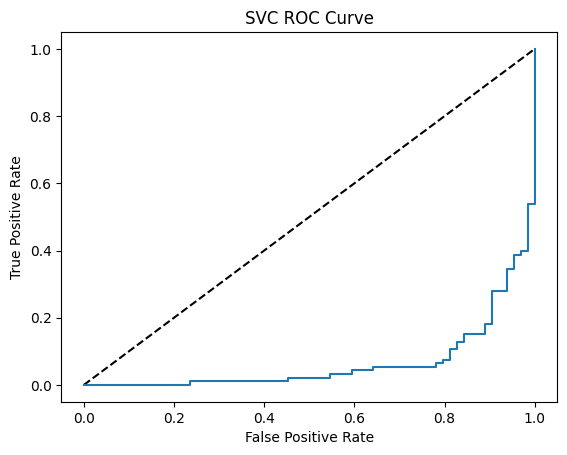

In [386]:
svm_model = SVC(kernel='rbf', C=100, gamma=0.1, probability=True, random_state=42) # initializing the model

model_score(svm_model, X_train_scaled,X_test_scaled, y_train, y_test, 'SVC ROC Curve')

### ***Random Forest Classifier***

In [387]:
best_params(RandomForestClassifier(), param_grid_rf, X_train_scaled, y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Meilleurs paramètres : {'model__max_depth': 20, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Meilleur score F1 (validation croisée) : 0.9330557775135533


Score = 0.9554140127388535
AUC score = 0.9899193548387097

confusion's matrix :
[[90  3]
 [ 4 60]]

classification's report :
                 precision    recall  f1-score   support

   appendicitis       0.96      0.97      0.96        93
no appendicitis       0.95      0.94      0.94        64

       accuracy                           0.96       157
      macro avg       0.95      0.95      0.95       157
   weighted avg       0.96      0.96      0.96       157





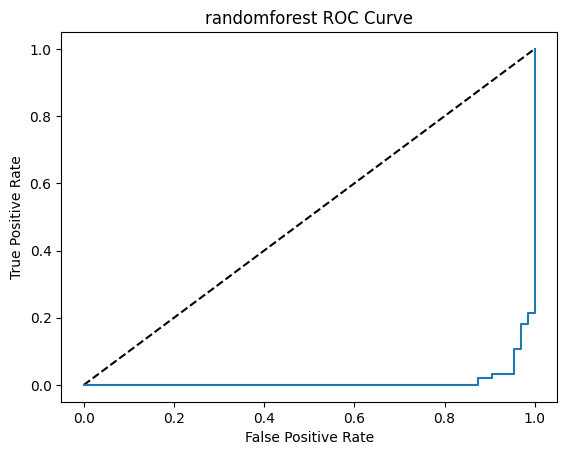

In [388]:
randomforest = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, min_samples_leaf=2, max_features='log2', random_state=42)

model_score(randomforest, X_train_scaled,X_test_scaled, y_train, y_test, 'randomforest ROC Curve')

### ***LightGBM Classifier***

In [389]:
best_params(LGBMClassifier(random_state=42, verbose=-1), param_grid_lgb, X_train_scaled, y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Meilleurs paramètres : {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__num_leaves': 15, 'model__scale_pos_weight': 1, 'model__subsample': 0.8}
Meilleur score F1 (validation croisée) : 0.9335336022831949


Score = 0.9554140127388535
AUC score = 0.9791666666666666

confusion's matrix :
[[91  2]
 [ 5 59]]

classification's report :
                 precision    recall  f1-score   support

   appendicitis       0.95      0.98      0.96        93
no appendicitis       0.97      0.92      0.94        64

       accuracy                           0.96       157
      macro avg       0.96      0.95      0.95       157
   weighted avg       0.96      0.96      0.96       157





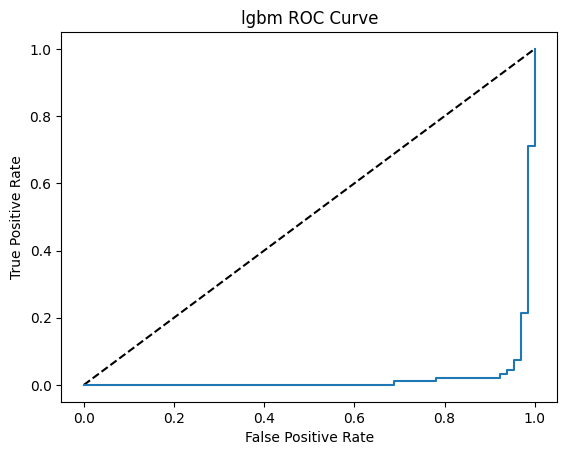

In [390]:
lgbm = LGBMClassifier(n_estimators=100, max_depth=3, learning_rate=.05, num_leaves=15, subsample=.8, colsample_bytree=1, scale_pos_weight=1)

model_score(lgbm, X_train_scaled,X_test_scaled, y_train, y_test, 'lgbm ROC Curve')

### ***CatBoost Classifier***

In [391]:
best_params(CatBoostClassifier(random_seed=42, verbose=0, allow_writing_files=False), param_grid_cat, X_train_scaled, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Meilleurs paramètres : {'model__depth': 6, 'model__iterations': 200, 'model__l2_leaf_reg': 3, 'model__learning_rate': 0.05, 'model__scale_pos_weight': 1}
Meilleur score F1 (validation croisée) : 0.9325430743980831


Score = 0.9426751592356688
AUC score = 0.9885752688172043

confusion's matrix :
[[90  3]
 [ 6 58]]

classification's report :
                 precision    recall  f1-score   support

   appendicitis       0.94      0.97      0.95        93
no appendicitis       0.95      0.91      0.93        64

       accuracy                           0.94       157
      macro avg       0.94      0.94      0.94       157
   weighted avg       0.94      0.94      0.94       157





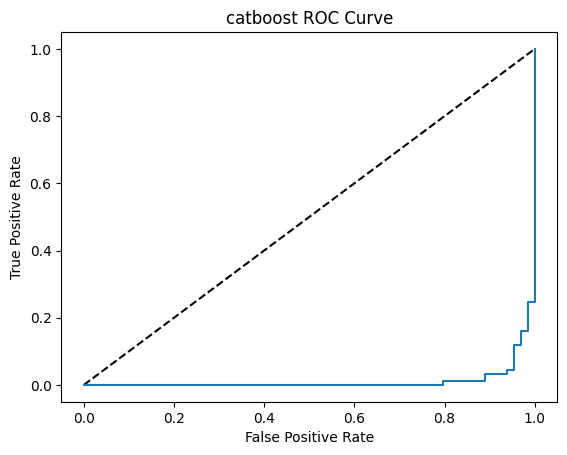

In [392]:
catboost = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.05, l2_leaf_reg=3, border_count=128, bagging_temperature=1, scale_pos_weight=1, verbose=0,)

model_score(catboost, X_train_scaled,X_test_scaled, y_train, y_test, 'catboost ROC Curve')

### ***SHAP Explainability***
--------------------------------------------------------

In [393]:
best_pipeline = grid_rf.best_estimator_

# Le modèle est directement accessible
if len(best_pipeline.steps) == 1:
    # La seule étape est le modèle
    model = best_pipeline.named_steps[list(best_pipeline.named_steps.keys())[0]]
    X_test_processed = pd.DataFrame(X_test_scaled)  # Pas de transformation nécessaire
else:
    # Sinon, extraire le modèle et le préprocesseur
    model = best_pipeline.named_steps['randomforest']
    # Créer préprocesseur avec les étapes avant le modèle
    preprocessor = Pipeline(best_pipeline.steps[:-1])
    X_test_processed = preprocessor.transform(X_test_scaled)

# Convertir en DataFrame si besoin
X_test_df = pd.DataFrame(X_test_processed, columns=X.columns)

# SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_df)
shap_values[0][ : 8]

array([[-0.1052122 ,  0.1052122 ],
       [ 0.01995735, -0.01995735],
       [-0.15087811,  0.15087811],
       [-0.02999531,  0.02999531],
       [ 0.00086736, -0.00086736],
       [-0.00090264,  0.00090264],
       [-0.00139766,  0.00139766],
       [ 0.01658252, -0.01658252]])

In [394]:
cols_used

['Length_of_Stay',
 'Alvarado_Score',
 'Appendix_Diameter',
 'WBC_Count',
 'Neutrophil_Percentage',
 'Segmented_Neutrophils',
 'Body_Temperature',
 'Paedriatic_Appendicitis_Score']

Indices trouvés: [5, 6, 9, 17, 18, 19, 16, 7]


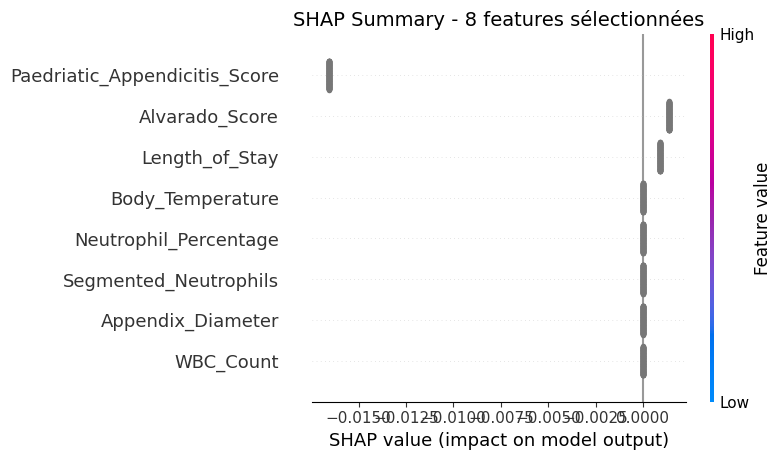

In [395]:
# Récupérer tous les noms de colonnes
all_features = list(X.columns)

# Trouver les indices de tes 8 features
indices = [all_features.index(f) for f in cols_used if f in all_features]
print(f"Indices trouvés: {indices}")

# Extraire seulement ces colonnes de shap_values
shap_values_selected = shap_values[:, indices, 1]  # : = tous les patients, indices = features choisies, 1 = classe positive
X_test_selected = X_test_df.iloc[:, indices]

# Créer un DataFrame avec les bons noms
X_test_selected_df = pd.DataFrame(X_test_selected, columns=cols_used)

# Plotter
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_selected, X_test_selected_df, 
                  feature_names=cols_used, show=False)
plt.title("SHAP Summary - 8 features sélectionnées", fontsize=14)
plt.tight_layout()
plt.show()

Indices trouvés: [5, 6, 9, 17, 18, 19, 16, 7]


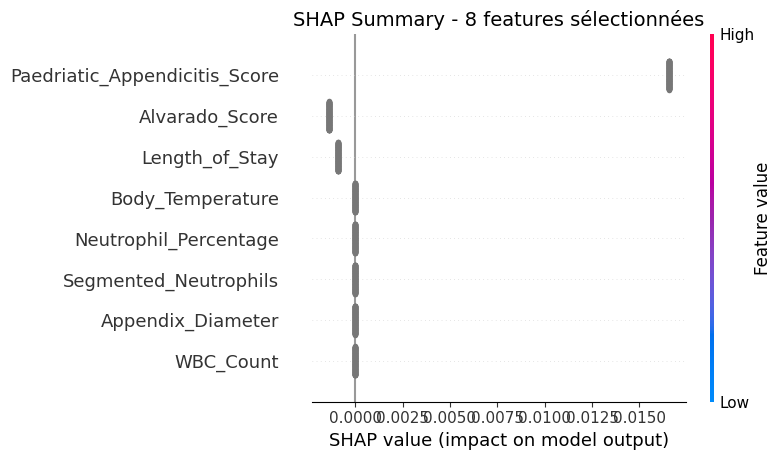

In [396]:
# Récupérer tous les noms de colonnes
all_features = list(X.columns)

# Trouver les indices de tes 8 features
indices = [all_features.index(f) for f in cols_used if f in all_features]
print(f"Indices trouvés: {indices}")

# Extraire seulement ces colonnes de shap_values
shap_values_selected = shap_values[:, indices, 0]  # : = tous les patients, indices = features choisies, 1 = classe positive
X_test_selected = X_test_df.iloc[:, indices]

# Créer un DataFrame avec les bons noms
X_test_selected_df = pd.DataFrame(X_test_selected, columns=cols_used)

# Plotter
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_selected, X_test_selected_df, 
                  feature_names=cols_used, show=False)
plt.title("SHAP Summary - 8 features sélectionnées", fontsize=14)
plt.tight_layout()
plt.show()

### ***Interface Development***
---------------------------------------------------------